In [60]:
import numpy as np
import xarray as xr
import pandas as pd 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

In [61]:
era5 = xr.open_dataset(r"D:\\Documents\\thesis\\processed_data\\era5-land-all-variables\\era5land_ebro_daily_mean.nc")
df = era5.to_dataframe()
df = df.drop(columns=['number', 'spatial_ref'])
df['day_of_year'] = df.index.dayofyear
df['tp_30d_sum'] = df['tp'].rolling(window=30, center=False).sum()
top_features = ['swvl1', 'ssrd', 'pev', 'day_of_year', 'swvl2', 'skt', 'tp_30d_sum']
df = df[top_features]

In [62]:
df.describe(percentiles=[0.01,0.05,0.95,0.99])

,swvl1,ssrd,pev,day_of_year,swvl2,skt,tp_30d_sum
count,5813.000000,5813.000000,5813.000000,5813.000000,5813.000000,5813.000000,5784.000000
mean,0.238542,8762.594727,9.832194,182.235335,0.248191,16.099615,75.975297
std,0.079765,4008.300537,5.749850,105.017940,0.061347,8.704317,52.687546
min,0.121167,812.507690,0.308460,1.000000,0.162170,-3.662584,0.488815
1%,0.123335,1941.782544,1.254749,4.000000,0.163918,0.910579,5.082610
5%,0.128315,3044.612646,1.863971,19.000000,0.168831,3.466411,12.576112
50%,0.236681,8710.440430,9.230940,182.000000,0.240385,15.435700,66.603100
95%,0.367512,14810.567969,19.314936,346.000000,0.349769,30.282645,176.960642
99%,0.401297,15388.608672,22.292478,362.000000,0.384853,32.915093,253.788897
max,0.432732,15932.156250,27.219023,366.000000,0.421590,35.328838,329.350014


Interquartile Range (IQR) Method

In [63]:
def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

outliers = df.apply(detect_outliers_iqr)
outliers.sum()

swvl1            0
ssrd             0
pev              0
day_of_year      0
swvl2            0
skt              0
tp_30d_sum     191
dtype: int64

z-score method

In [64]:
z = np.abs(zscore(df))
outliers = (z > 3)
outliers.sum()

np.int64(1)

The dataset does not show evidence of outliers because all variables fall within physically realistic ranges, their statistical distributions are well behaved, and the relationships between variables are consistent with hydrological processes.

Time Series Outlier Detection

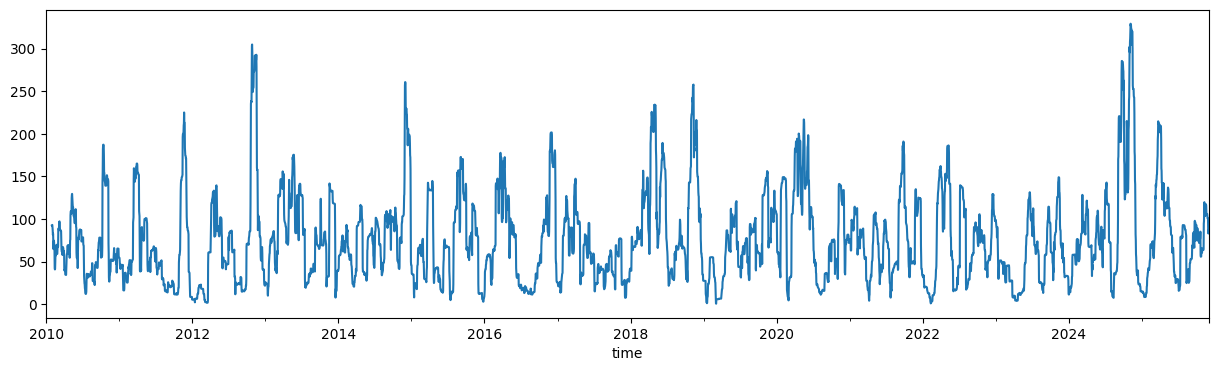

In [65]:
df['tp_30d_sum'].plot(figsize=(15,4))
plt.show()

Boxplots

<Axes: >

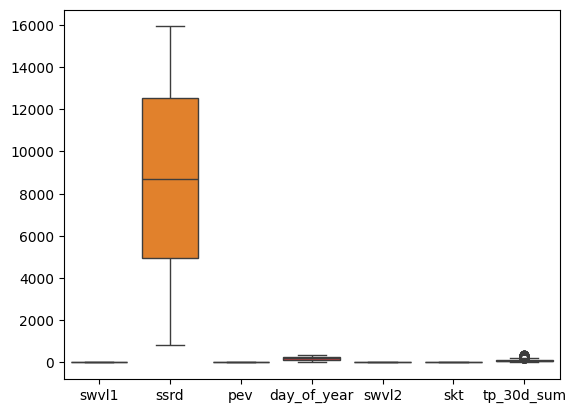

In [66]:
sns.boxplot(data=df)

<Axes: >

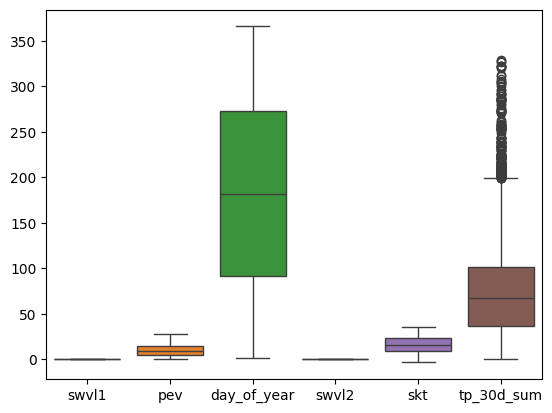

In [67]:
sns.boxplot(data=df[['swvl1', 'pev', 'day_of_year', 'swvl2', 'skt', 'tp_30d_sum']])

In [68]:
corr = df[['swvl1','swvl2','tp_30d_sum','pev','ssrd','skt']].corr()
print(corr['swvl1'])

swvl1         1.000000
swvl2         0.915603
tp_30d_sum    0.547376
pev          -0.717701
ssrd         -0.681512
skt          -0.745103
Name: swvl1, dtype: float64


<Axes: xlabel='day_of_year'>

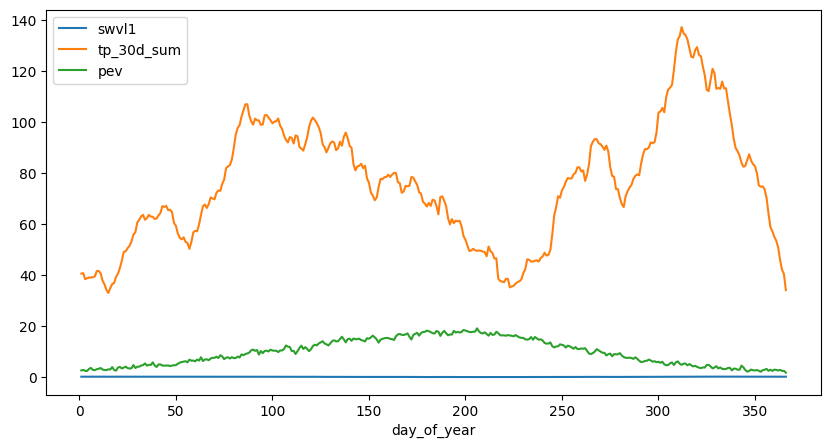

In [69]:
season = df.groupby('day_of_year')[['swvl1','tp_30d_sum','pev']].mean()
season.plot(figsize=(10,5))

<Axes: xlabel='time'>

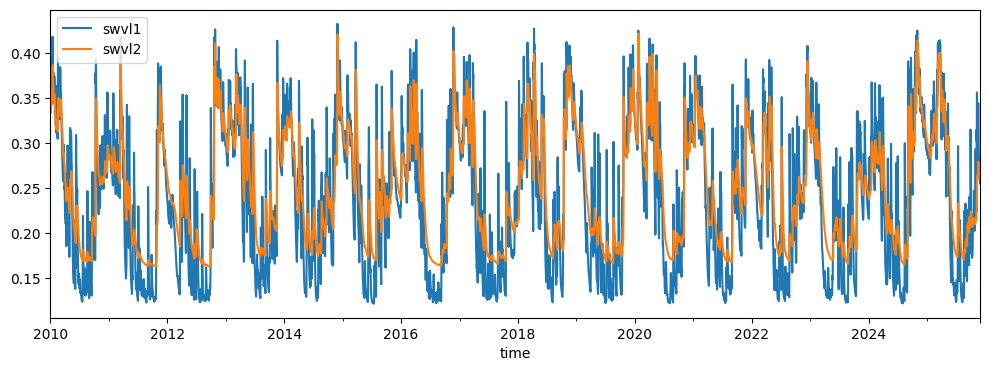

In [70]:
df[['swvl1','swvl2']].plot(figsize=(12,4))

In [71]:
df['sm_change'] = df['swvl1'].diff()
print(df[['sm_change','tp_30d_sum']].corr())

            sm_change  tp_30d_sum
sm_change    1.000000   -0.023059
tp_30d_sum  -0.023059    1.000000


<Axes: xlabel='tp_30d_sum', ylabel='swvl1'>

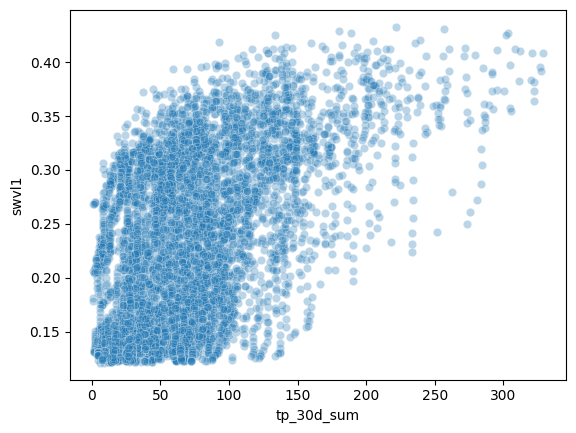

In [72]:
sns.scatterplot(x=df['tp_30d_sum'], y=df['swvl1'], alpha=0.3)

PCA

In [73]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [74]:
df = era5.to_dataframe()
df = df.drop(columns=['number', 'spatial_ref'])
df["target"] = df["swvl1"].shift(-30)
df_model = df.dropna()
drop_cols = ["target", "swvl1"]

df_model['month'] = df_model.index.month
df_model['day_of_year'] = df_model.index.dayofyear
df_model['tp_30d_sum'] = df_model['tp'].rolling(window=30, center=False).sum()
df_model['tp_90d_sum'] = df_model['tp'].rolling(window=90, center=False).sum()

df_model = df_model.dropna()

X = df_model.drop(columns=drop_cols)
y = df_model["target"]

split = int(len(df_model) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

C:\Users\albat\AppData\Local\Temp\ipykernel_17464\3779075300.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['month'] = df_model.index.month
C:\Users\albat\AppData\Local\Temp\ipykernel_17464\3779075300.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['day_of_year'] = df_model.index.dayofyear
C:\Users\albat\AppData\Local\Temp\ipykernel_17464\3779075300.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_inde

In [75]:
# It is best to use a Pipeline to avoid data leakage
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('rf', RandomForestRegressor(max_depth=5, random_state=42))
])

pipeline.fit(X_train, y_train)
print(f"PCA Test R²: {pipeline.score(X_test, y_test)}")

PCA Test R²: 0.3340716995272208


In [76]:
# It is best to use a Pipeline to avoid data leakage
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=4)),
    ('rf', RandomForestRegressor(max_depth=5, random_state=42))
])

pipeline.fit(X_train, y_train)
print(f"PCA Test R²: {pipeline.score(X_test, y_test)}")

PCA Test R²: 0.40328318496170423


In [77]:
# It is best to use a Pipeline to avoid data leakage
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=6)),
    ('rf', RandomForestRegressor(max_depth=5, random_state=42))
])

pipeline.fit(X_train, y_train)
print(f"PCA Test R²: {pipeline.score(X_test, y_test)}")

PCA Test R²: 0.41027268668154326


In [78]:
# It is best to use a Pipeline to avoid data leakage
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=9)),
    ('rf', RandomForestRegressor(max_depth=5, random_state=42))
])

pipeline.fit(X_train, y_train)
print(f"PCA Test R²: {pipeline.score(X_test, y_test)}")

PCA Test R²: 0.39024439845689285


In [79]:
# It is best to use a Pipeline to avoid data leakage
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10)),
    ('rf', RandomForestRegressor(max_depth=5, random_state=42))
])

pipeline.fit(X_train, y_train)
print(f"PCA Test R²: {pipeline.score(X_test, y_test)}")

PCA Test R²: 0.3937108298712366


In [80]:
top_features = ['target', 'ssrd', 'pev', 'day_of_year', 'swvl2', 'skt', 'tp_30d_sum']
X = df_model[top_features].drop(columns=['target'])
y = df_model["target"]

split = int(len(df_model) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [81]:
# It is best to use a Pipeline to avoid data leakage
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=4)),
    ('rf', RandomForestRegressor(max_depth=5, random_state=42))
])

pipeline.fit(X_train, y_train)
print(f"PCA Test R²: {pipeline.score(X_test, y_test)}")

PCA Test R²: 0.4236351997684805
